# The MALA Algorithm

Let us see how the MALA algorithm works, and how it performs better than RWM when the dimension $d$ is large. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

## RWM

Let us first recall how the random walk Metropolis algorithm works. Consider sampling from the following one-dimensional density. 

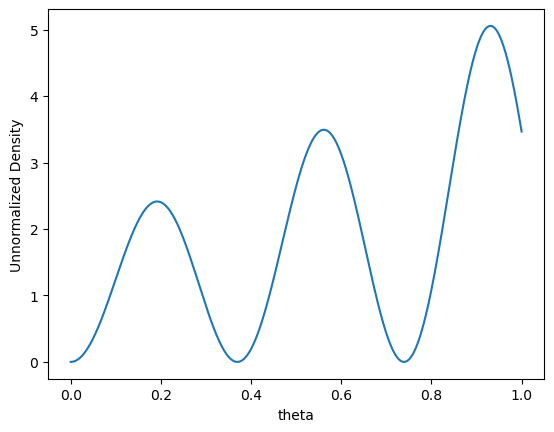

In [2]:
def f(th): 
    return (np.sin(8.5 * th) ** 2) * (th >= 0) * (th <= 1) * 2*np.exp(th)

th = np.arange(0, 1.001, 0.001)
plt.plot(th, f(th))
plt.xlabel("theta")
plt.ylabel("Unnormalized Density")
plt.show()

The above function is not a quite a density because it does not integrate to one. Its integral is given by:

In [3]:
from scipy.integrate import quad
val, err = quad(f, 0, 1)
print(val)

1.8775056565536072


Below is the Random-Walk Metropolis (RWM) algorithm for obtaining $N = 40000$ samples approximating this density. We shall use the proposals generated as $N(x, \sigma^2)$. The choice of $\sigma$ is crucial for the performance of RWM. In this example, $\sigma = 0.3$ seems to work well. 

Rejection rate: 0.56255


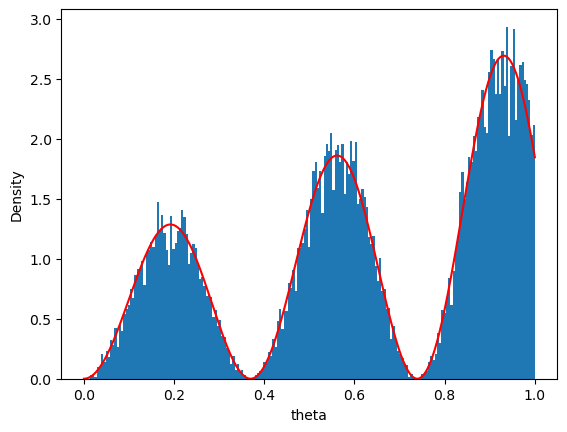

In [4]:
nit = 40000
path = np.empty(nit)
state = 0.4 #initialization
path[0] = state
rej = 0
sig = 0.3

for i in range(1, nit):
    candidate = np.random.normal(loc = state, scale = sig)
    ratio = f(candidate) / f(state)
    rnum = np.random.uniform(0, 1)
    if rnum >= ratio: 
        rej += 1
    else:
        state = candidate
    path[i] = state

print("Rejection rate:", rej / nit)

plt.hist(path, bins = 200, density = True)
plt.xlabel("theta")
plt.ylabel("Density")
plt.plot(th, f(th)/val, color = "red")
plt.show()

Below is the 'trace plot' (i.e., plot of $\theta^{(t)}$) for the last 2000 iterations. 

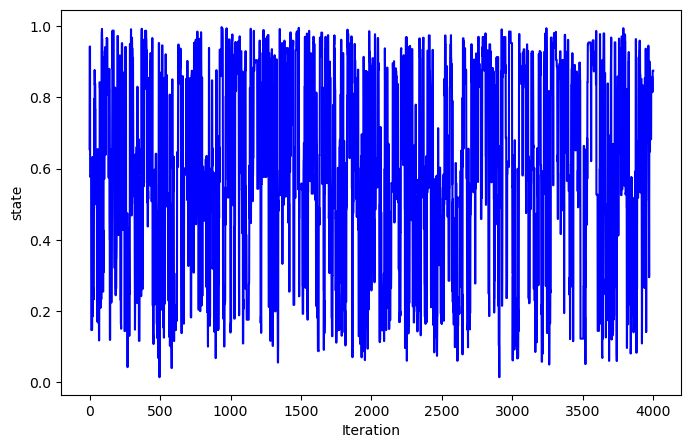

In [5]:
#Here are the last 4000 iterations of the path: 
plt.figure(figsize = (8, 5))
plt.plot(path[nit-4000:], color = "blue")
plt.xlabel("Iteration")
plt.ylabel("state")
plt.show()

Below is the autocorrelation plot for the chain. 

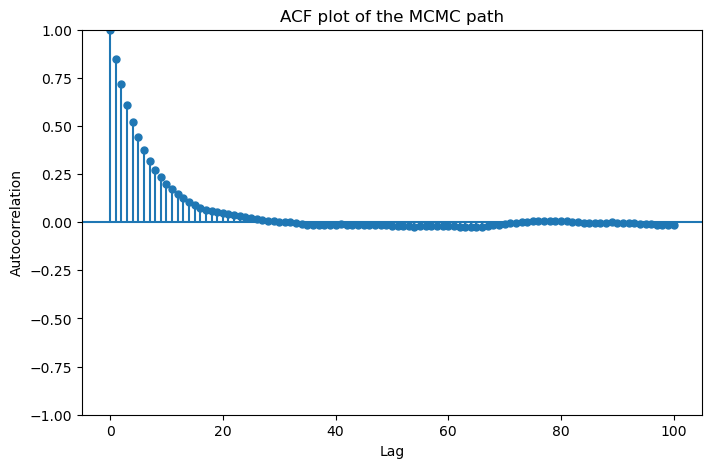

In [6]:
# Autocorrelation plot
plt.figure(figsize=(8,5))
plot_acf(path, lags=100, fft=True, alpha=None, ax=plt.gca())
plt.title("ACF plot of the MCMC path")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.show()

The autocorrelations are decaying rapidly indicating good mixing. 

In the last lecture, we converted the above 1D example into a higher dimensional example by adding $X_2, \dots, X_d$ having i.i.d $N(0, 1)$ distribution. We also saw that the RWM algorithm does not quite work here for obtaining $N = 40000$ samples. We would need to take a much larger $N$ for getting good approximations to the distribution of the first coordinate using RWM. This can be checked using the code below. No matter what value of $\sigma$ is used, RWM provides a poor approximation for the density of the first coordinate.  

Rejection rate: 0.75475


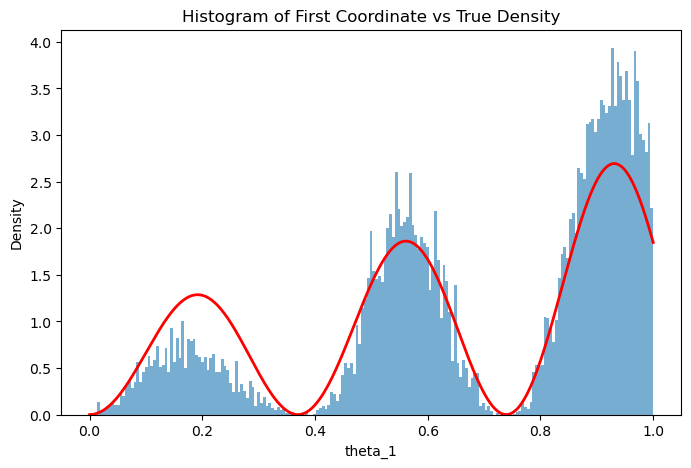

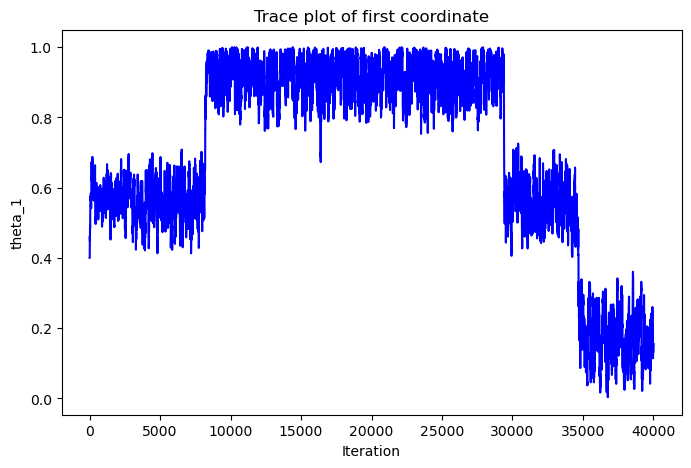

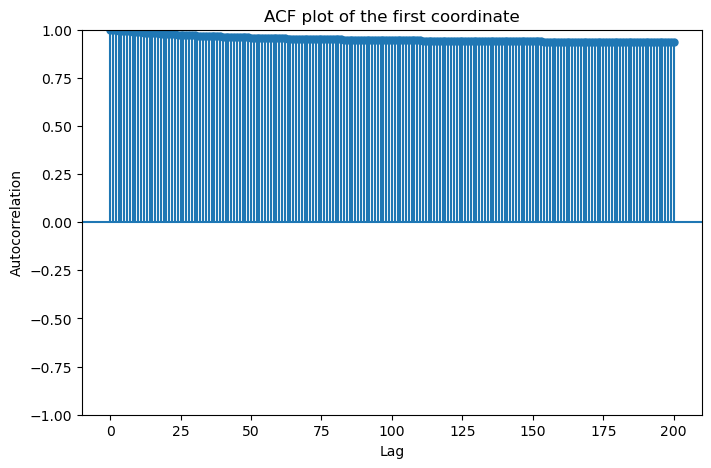

In [8]:
# log of standard normal density (up to constant)
def log_phi(x):
    return -0.5 * x**2

# dimension
d = 5000

# grid for plotting true density
th = np.arange(0, 1.001, 0.001)
f_vals = f(th)
val = np.trapezoid(f_vals, th)  # normalization for plotting

# RWM parameters
nit = 40000
path = np.empty(nit)  # store only first coordinate
state = np.zeros(d)
state[0] = 0.4  # initialize first coordinate
path[0] = state[0]

rej = 0
#sig = 0.3  # this is WAY too big in high d
sig = 0.03 #Repeat this code a few times to see how the approximation to the histogram changes for each run. 
#sig = 0.16
#sig = 0.01
#sig = 0.01 #does not work
#sig = 0.003 #this is too small

for i in range(1, nit):
    # propose full d-dimensional move
    candidate = state + np.random.normal(0, sig, size=d)
    
    # compute log acceptance ratio
    log_ratio = 0.0
    
    # first coordinate contribution
    f_cand = f(candidate[0])
    f_curr = f(state[0])
    
    if f_cand == 0:
        log_ratio = -np.inf
    elif f_curr == 0:
        log_ratio = np.inf
    else:
        log_ratio += np.log(f_cand) - np.log(f_curr)
    
    # remaining coordinates (Gaussian)
    log_ratio += np.sum(log_phi(candidate[1:]) - log_phi(state[1:]))
    
    # accept/reject
    if np.log(np.random.uniform()) >= log_ratio:
        rej += 1
    else:
        state = candidate
    
    path[i] = state[0]

print("Rejection rate:", rej / nit)

# Histogram vs true density
plt.figure(figsize=(8,5))
plt.hist(path, bins=200, density=True, alpha=0.6)
plt.plot(th, f_vals / val, color="red", linewidth=2)
plt.xlabel("theta_1")
plt.ylabel("Density")
plt.title("Histogram of First Coordinate vs True Density")
plt.show()

# Trace plot of first coordinate
plt.figure(figsize=(8,5))
plt.plot(path, color="blue")
plt.xlabel("Iteration")
plt.ylabel("theta_1")
plt.title("Trace plot of first coordinate")
plt.show()

# Autocorrelation plot
plt.figure(figsize=(8,5))
plot_acf(path, lags=200, fft=True, alpha=None, ax=plt.gca())
plt.title("ACF plot of the first coordinate")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.show()

## MALA

Now we shall how MALA works for this problem. Recall that the MALA proposal is: 
\begin{align*}
   y = x + \frac{1}{2} \sigma^2 \nabla \log \pi(x) + \sigma z
\end{align*}
with $z \sim N(0, I_d)$. In contrast to RWM, it is possible to choose a reasonable value of $\sigma$ to obtain a good approximation to the true density of the first coordinate with $N = 40000$. This is demonstrated below.

Rejection rate: 0.61865


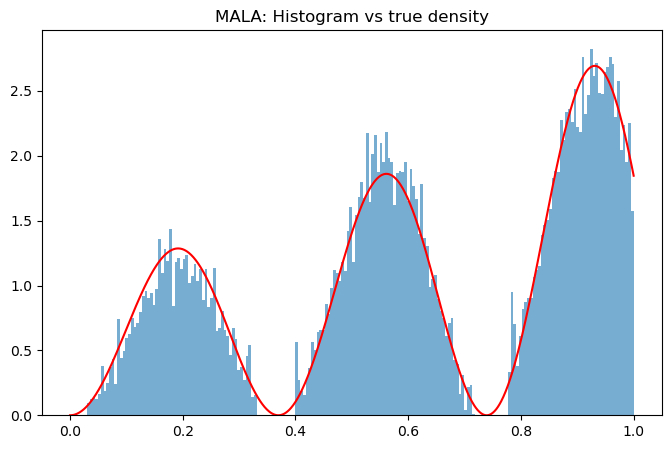

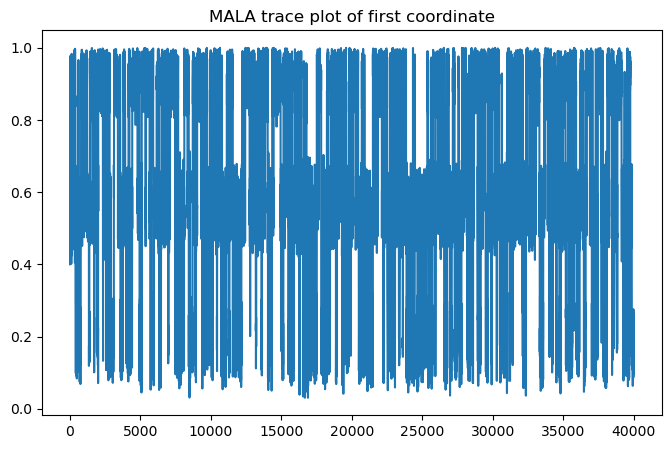

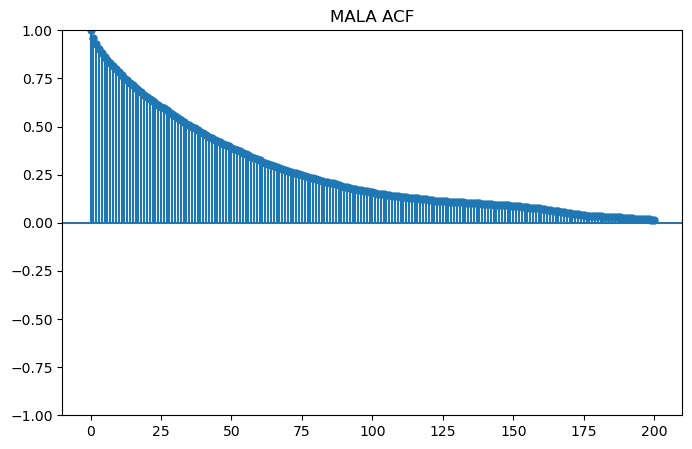

In [ ]:
# numerical gradient of log f
def grad_log_f(th):
    eps = 1e-6
    return (np.log(f(th + eps) + 1e-12) - np.log(f(th - eps) + 1e-12)) / (2*eps)

# dimension
d = 5000

# plotting normalization
th = np.arange(0, 1.001, 0.001)
f_vals = f(th)
val = np.trapezoid(f_vals, th)

# MALA parameters
nit = 40000
sig = 0.16 #this value seems to work well. 
path = np.empty(nit)

state = np.zeros(d)
state[0] = 0.4
path[0] = state[0]

rej = 0

for i in range(1, nit):
    # gradient of log target
    grad = np.zeros(d)
    grad[0] = grad_log_f(state[0])
    grad[1:] = -state[1:]   # Gaussian part
    
    # proposal
    mean_forward = state + 0.5 * (sig ** 2) * grad
    candidate = mean_forward + sig * np.random.normal(size=d)
    
    # gradient at candidate
    grad_cand = np.zeros(d)
    grad_cand[0] = grad_log_f(candidate[0])
    grad_cand[1:] = -candidate[1:]
    
    mean_backward = candidate + 0.5 * (sig ** 2) * grad_cand
    
    # log target ratio
    f_cand = f(candidate[0])
    f_curr = f(state[0])
    
    if f_cand == 0:
        log_ratio = -np.inf
    elif f_curr == 0:
        log_ratio = np.inf
    else:
        log_ratio = np.log(f_cand) - np.log(f_curr)
    
    log_ratio += -0.5*np.sum(candidate[1:]**2) + 0.5*np.sum(state[1:]**2)
    
    # proposal correction (Gaussian densities)
    log_q_forward = -np.sum((candidate - mean_forward)**2) / (2*(sig**2))
    log_q_backward = -np.sum((state - mean_backward)**2) / (2*(sig**2))
    
    log_ratio += log_q_backward - log_q_forward
    
    # accept/reject
    if np.log(np.random.uniform()) >= log_ratio:
        rej += 1
    else:
        state = candidate
    
    path[i] = state[0]

print("Rejection rate:", rej / nit)

# histogram
plt.figure(figsize=(8,5))
plt.hist(path, bins=200, density=True, alpha=0.6)
plt.plot(th, f_vals / val, color="red")
plt.title("MALA: Histogram vs true density")
plt.show()

# trace
plt.figure(figsize=(8,5))
plt.plot(path)
plt.title("MALA trace plot of first coordinate")
plt.show()

# ACF 
plt.figure(figsize=(8,5))
plot_acf(path, lags=200, fft=True, alpha=None, ax=plt.gca())
plt.title("MALA ACF")
plt.show()

This shows that MALA can be much more effective compared to RWM for large $d$. 

## Proposals of RWM, MALA, HMC when $\pi = N(0, I_d)$

Let us plot the proposals of RWM, MALA, HMC when the true density is $N(0, I_d)$. In this case, note that $\nabla \log \pi(x) = -x$ so that: 
\begin{align*}
   y_{RWM} = x + \sigma z
\end{align*}

\begin{align*}
   y_{MALA} = \left(1 - (\sigma^2/2) \right) x + \sigma z
\end{align*}

\begin{align*}
   y_{HMC} = x \cos \sigma + z \sin \sigma. 
\end{align*}

Below we plot each of these proposals for fixed $x, z$ and $\sigma$. 

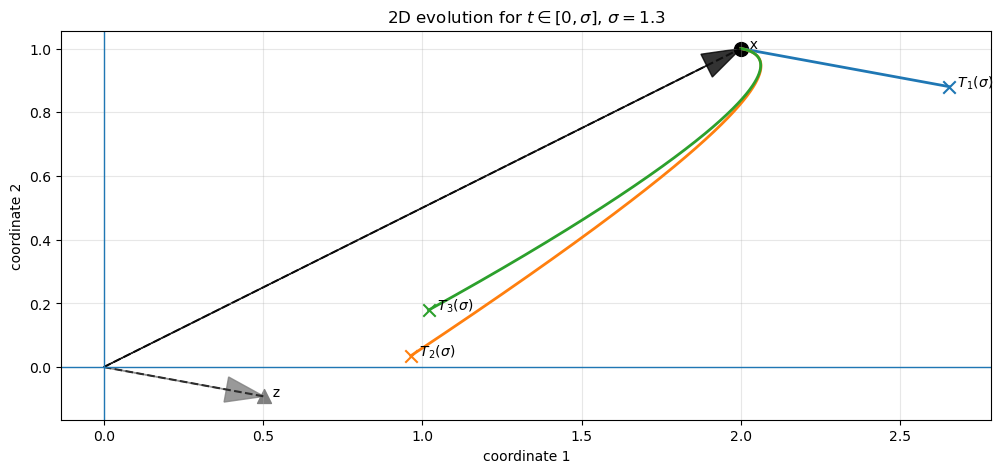

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# parameters
sigma = 1.3
x = np.array([2.0, 1.0])

# one fixed draw z ~ N(0, I_2)
#np.random.seed(0)
z = np.random.randn(2)

# time grid
t = np.linspace(0, sigma, 300)

# trajectories
T1 = x[None, :] + t[:, None] * z[None, :]
T2 = (1 - t**2 / 2)[:, None] * x[None, :] + t[:, None] * z[None, :]
T3 = np.cos(t)[:, None] * x[None, :] + np.sin(t)[:, None] * z[None, :]

# endpoints
T1_end = T1[-1]
T2_end = T2[-1]
T3_end = T3[-1]

plt.figure(figsize=(12, 6))

# trajectories
plt.plot(T1[:, 0], T1[:, 1], linewidth=2, label=r"$T_1(t)=x+t z$")
plt.plot(T2[:, 0], T2[:, 1], linewidth=2, label=r"$T_2(t)=(1-t^2/2)x+t z$")
plt.plot(T3[:, 0], T3[:, 1], linewidth=2, label=r"$T_3(t)=x\cos t+z\sin t$")

# connect origin to x and z
plt.plot([0, x[0]], [0, x[1]], 'k--', alpha=0.7)
plt.plot([0, z[0]], [0, z[1]], 'k--', alpha=0.7)

# arrows from origin to x and z
plt.arrow(0, 0, x[0], x[1],
          head_width=0.08, length_includes_head=True, alpha=0.8, color='black')
plt.arrow(0, 0, z[0], z[1],
          head_width=0.08, length_includes_head=True, alpha=0.8, color='gray')

# mark x and z
plt.scatter(x[0], x[1], s=100, marker='o', color='black', label="x")
plt.scatter(z[0], z[1], s=100, marker='^', color='gray', label="z")

# mark endpoints
plt.scatter(T1_end[0], T1_end[1], s=80, marker='x')
plt.scatter(T2_end[0], T2_end[1], s=80, marker='x')
plt.scatter(T3_end[0], T3_end[1], s=80, marker='x')

plt.text(x[0], x[1], "  x")
plt.text(z[0], z[1], "  z")
plt.text(T1_end[0], T1_end[1], r"  $T_1(\sigma)$")
plt.text(T2_end[0], T2_end[1], r"  $T_2(\sigma)$")
plt.text(T3_end[0], T3_end[1], r"  $T_3(\sigma)$")

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, alpha=0.3)
#plt.legend()
plt.title(fr"2D evolution for $t\in[0,\sigma]$, $\sigma={sigma}$")
plt.xlabel("coordinate 1")
plt.ylabel("coordinate 2")
plt.show()

It is clear that the RWM proposal is a straight line starting from $x$ in the direction given by $z$. The MALA proposal is curved and represents a parabola. The HMC proposal is even more curved compared to MALA. HMC and MALA are fairly close when $\sigma$ is small but they diverge for larger values of $t$. These curved proposals work better in larger dimensions compared to straight line RWM proposals. 